# Fig M7 / Fig S17 — KRAS-resistance drivers via analytic Gaussian posterior

Reproduces the pancreatic naive-vs-resistant supplement. An analytic Gaussian
posterior is fit on the mean expression shift of significant high-LFC genes;
genes are scored by **CIPHER score** `log(1 + |posterior mean μ|)` and ranked
by `|μ|`. Panels: posterior `|z|` and `log(1+|μ|)` vs `|μ|`-rank, `log(1+|μ|)`
vs positive log2FC, CIPHER-rank vs LFC-rank, curve redraws with labelled tracked
genes, and naive-control ranked mean-expression panels.

Engine: `notebooks/src/suppl_resistance.py` (a helper in `notebooks/src`, not part of the
cipher package). **Data:** `pancreatic_naive_vs_resistant.h5ad` under `$CIPHER_DATA_DIR/suppl`.
All `.npy`/`.tsv` intermediates are computed by the first cell; nothing is pre-loaded.


In [1]:
import os, sys
# route tqdm progress bars to text (stderr -> log) instead of un-renderable ipywidgets
import importlib as _il
try:
    _std_tqdm = _il.import_module('tqdm.std').tqdm
    for _m in ('tqdm', 'tqdm.auto', 'tqdm.notebook', 'tqdm.autonotebook'):
        try: _il.import_module(_m).tqdm = _std_tqdm
        except Exception: pass
except Exception:
    pass
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "suppl" else os.getcwd())

from src.suppl_resistance import *

DATA_DIR = os.environ["CIPHER_DATA_DIR"]
SUPPL = os.path.join(DATA_DIR, "suppl")
OUTDIR = os.environ.get("SUPPL_OUT", "resources/repro/figM7_S17")
os.makedirs(OUTDIR, exist_ok=True)
from src.logutil import route_logs  # verbose logs -> .log, plots stay in-cell
route_logs("kras_resistance_figM7_S17")

# stable repro base (the pipeline reassigns a local `OUTDIR`, so keep the base here)
_BASE = OUTDIR
H5AD_PATH = os.path.join(SUPPL, "pancreatic_naive_vs_resistant.h5ad")

[logs] verbose output -> ../../resources/repro/figM7_S17/logs/kras_resistance_figM7_S17.log


In [2]:
import src.run_kras_resistance as R
import src.suppl_resistance as C
_cfg = {k: v for k, v in globals().items() if k.isupper() or k in ("DATA_DIR", "SUPPL", "OUTDIR")}
R.__dict__.update(_cfg)
C.__dict__.update(_cfg)

## Fit analytic Gaussian posterior on top significant high-LFC genes

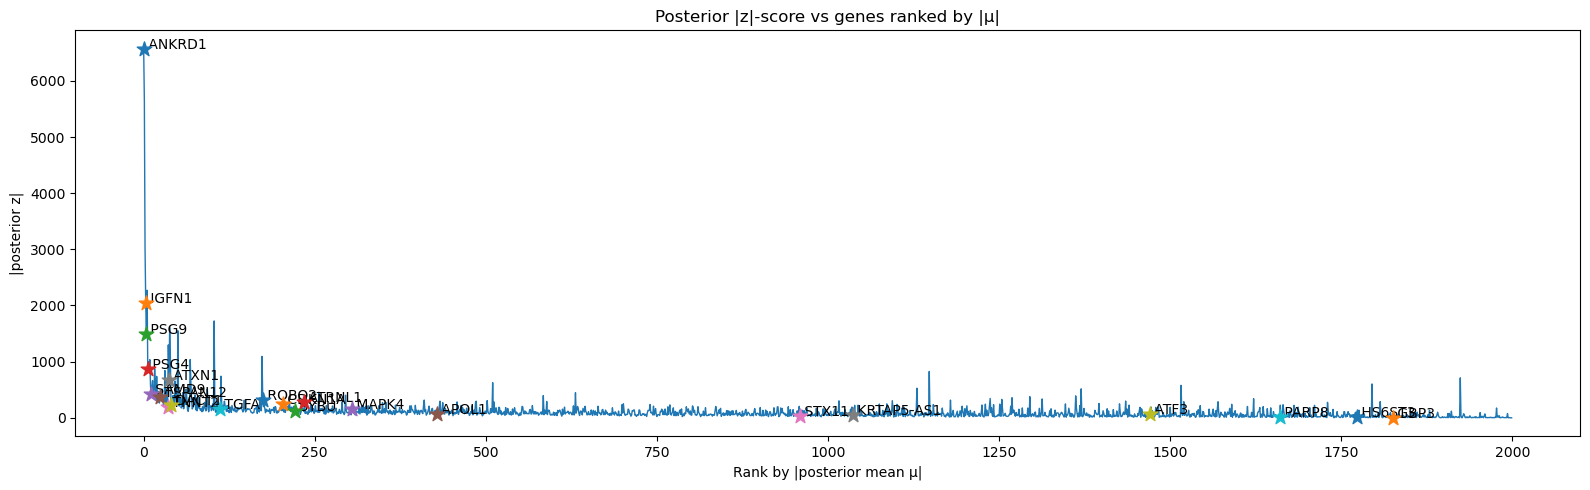

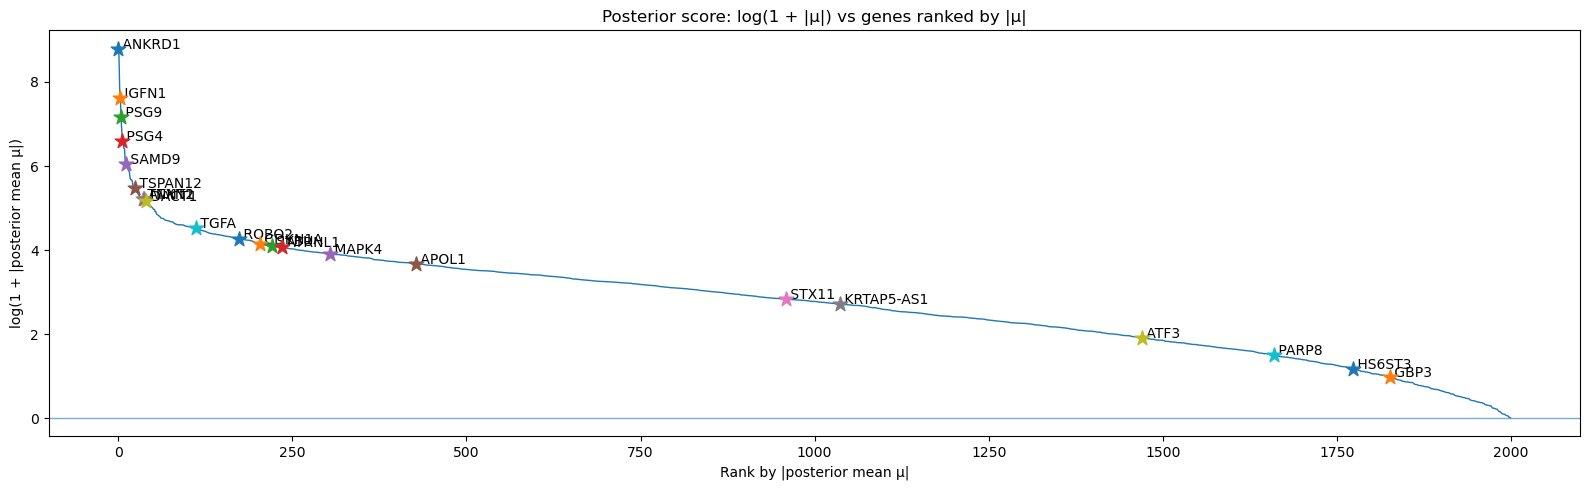

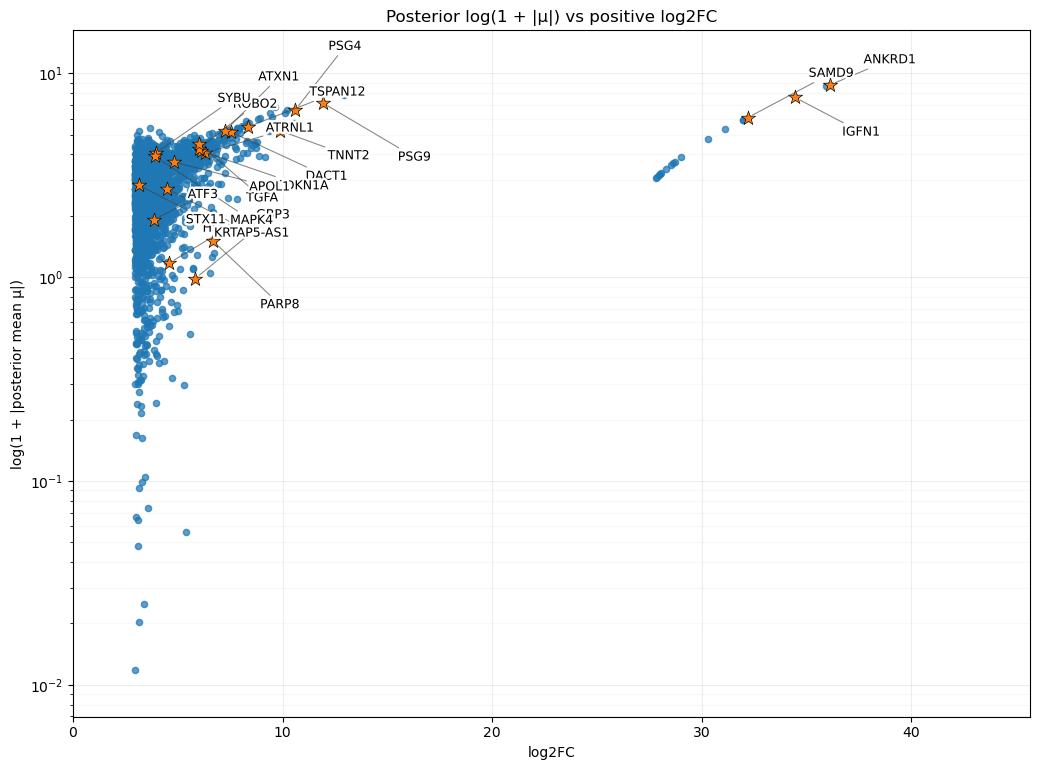

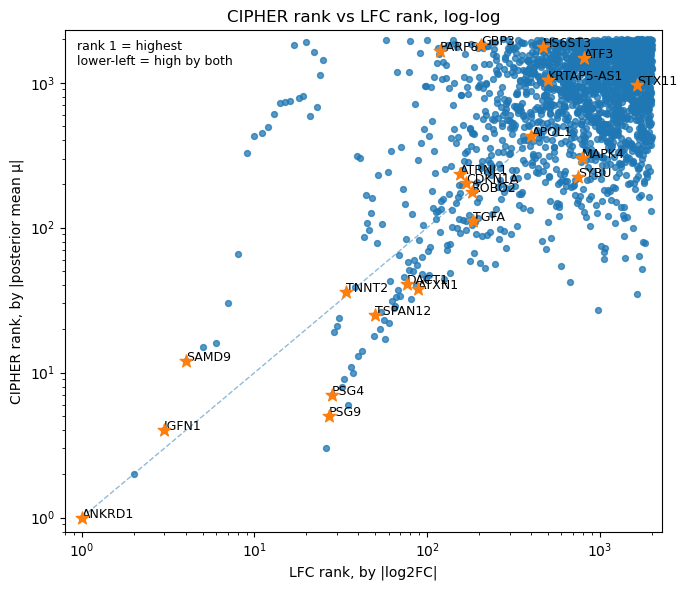

In [3]:
R.run_gaussian_pipeline()

## Posterior score $\log(1+|\mu|)$ vs genes ranked by $|\mu|$ (labelled tracked genes)

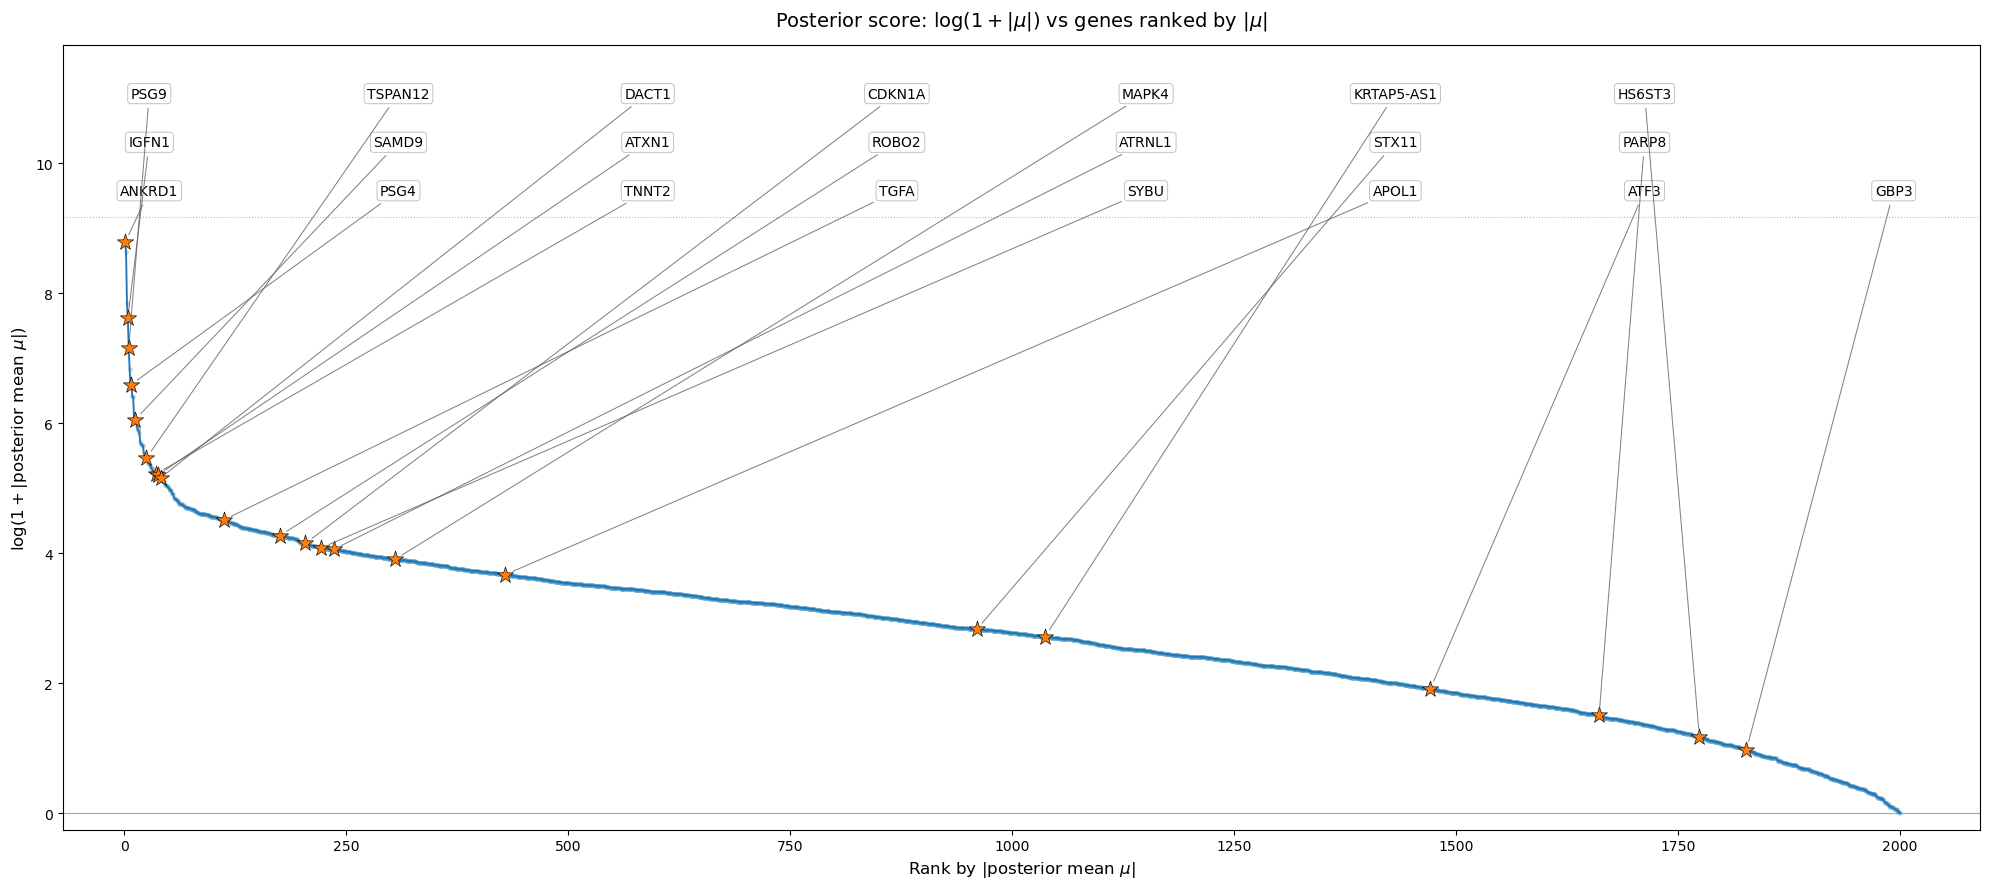

In [4]:
R.fig_posterior_score_curve()

## CIPHER-rank vs LFC-rank curve with labelled tracked genes

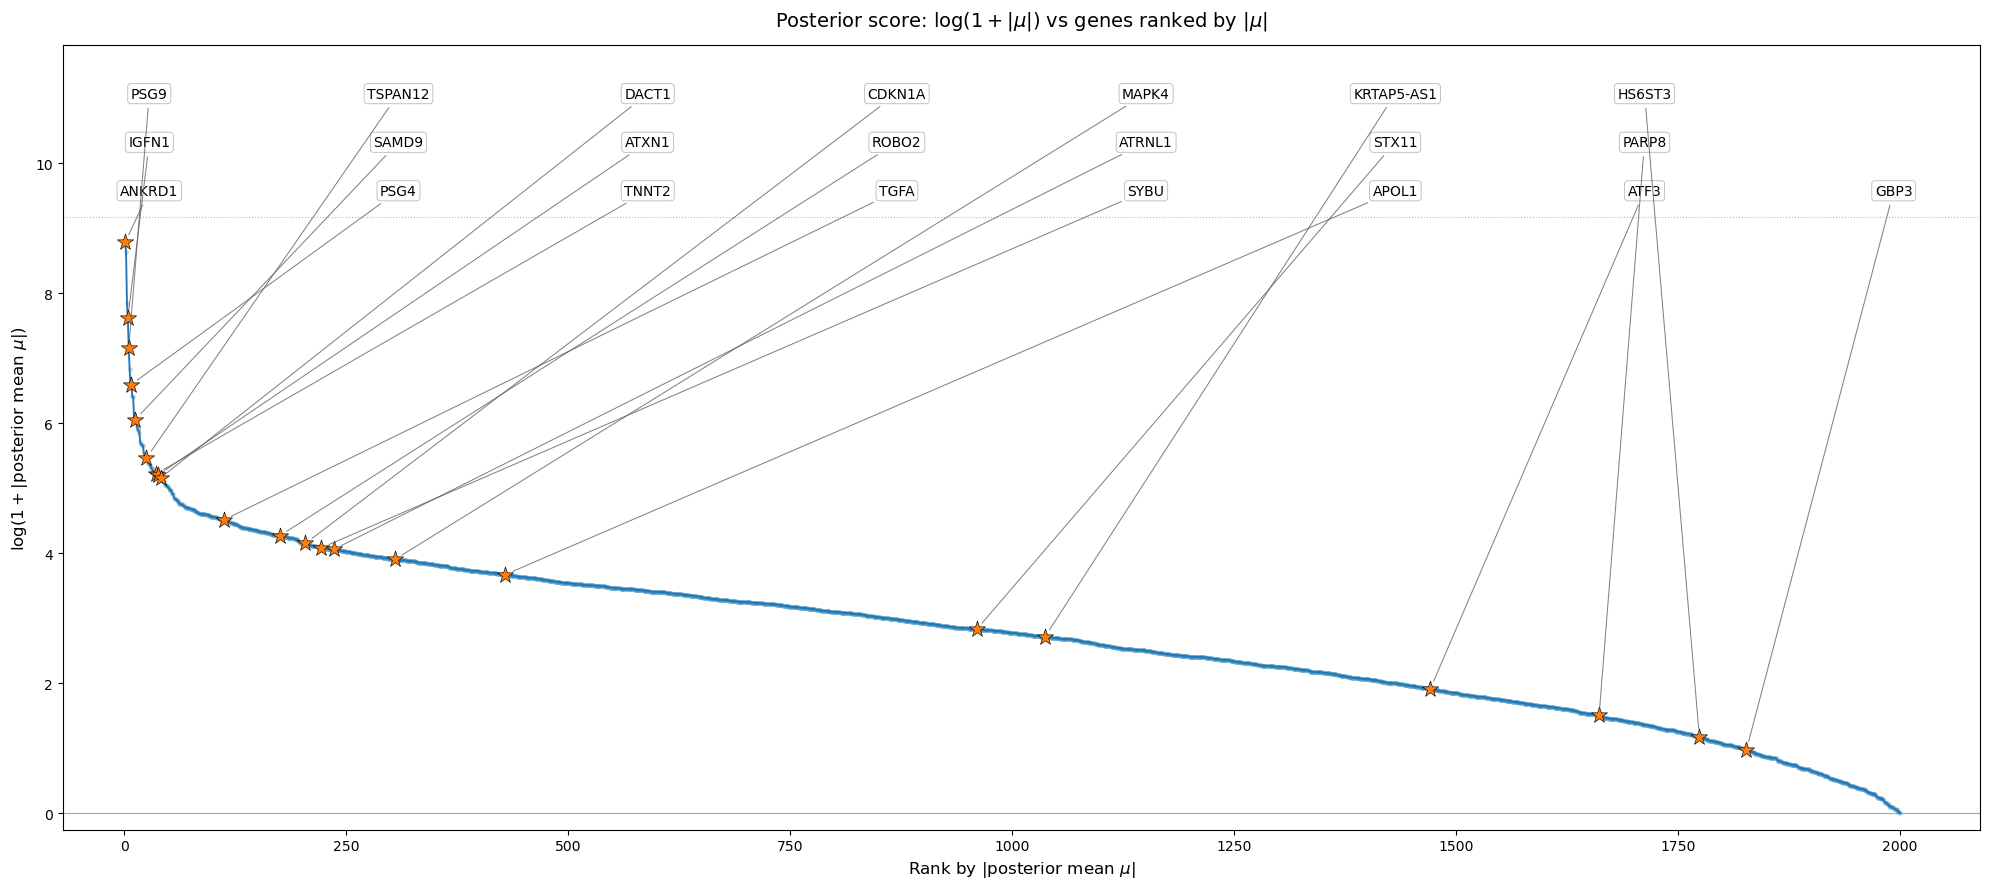

In [5]:
R.fig_cipher_rank_lfc_curve()

## CIPHER-score curve with green/grey tracked-gene groups

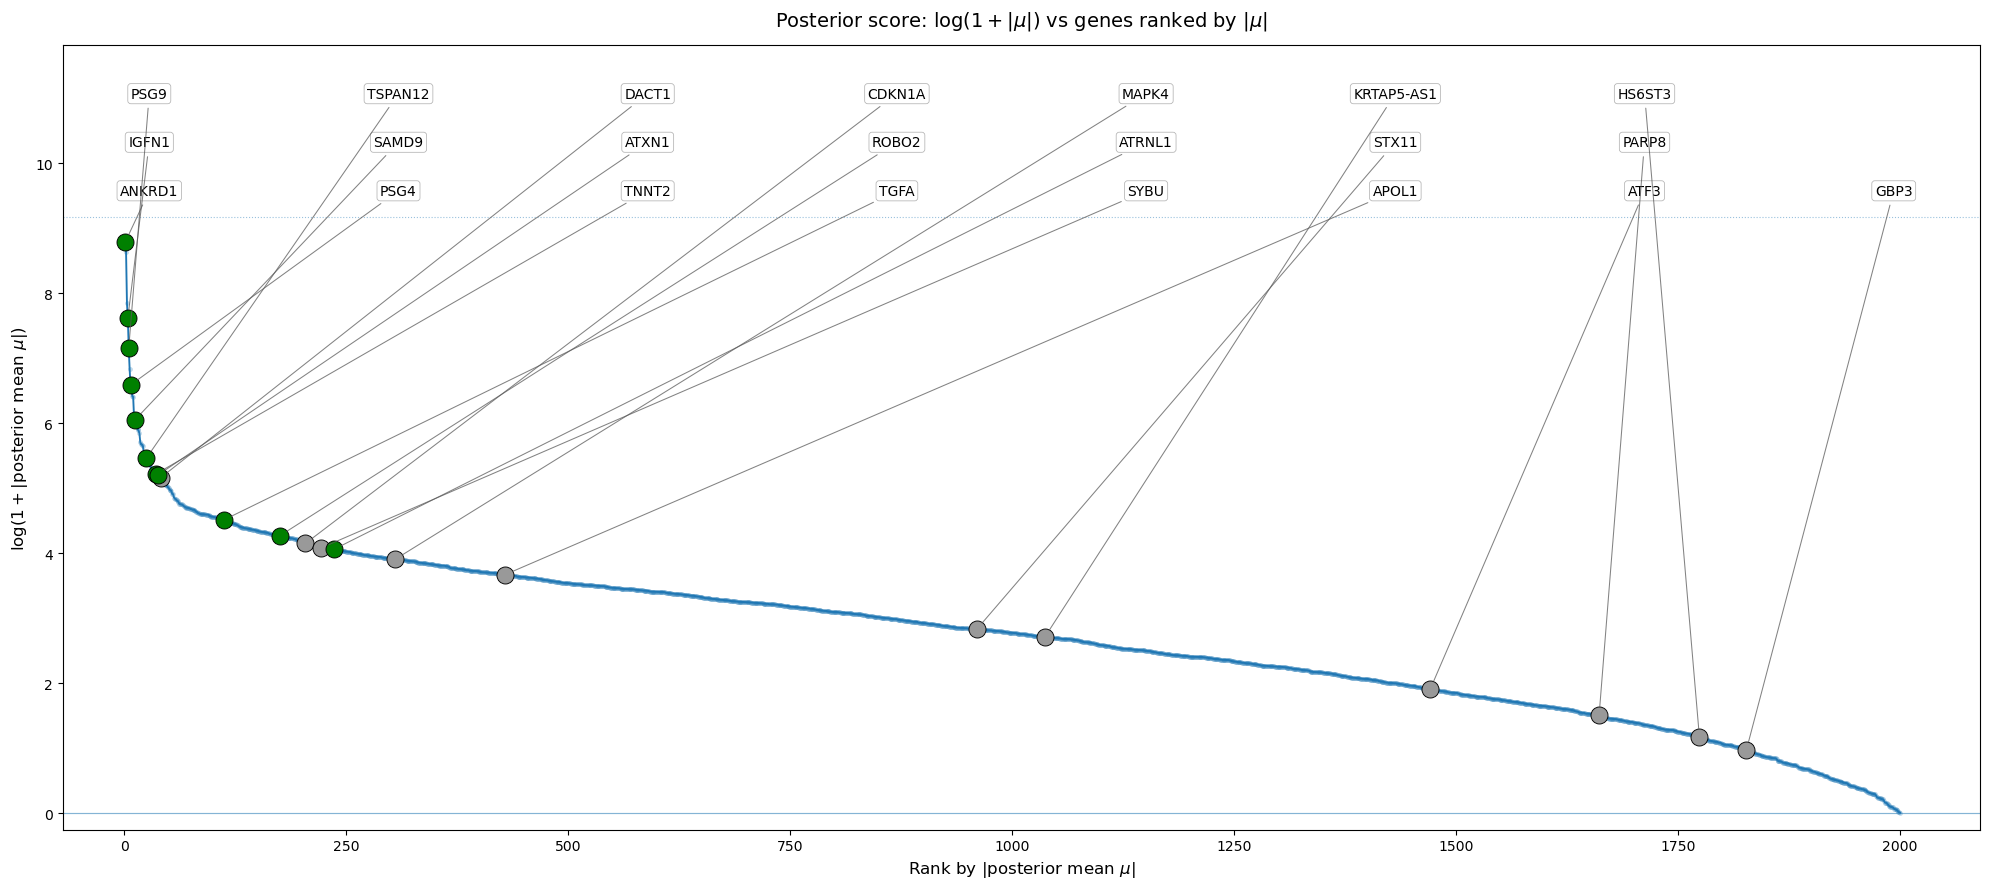

In [6]:
R.fig_cipher_rank_green_grey()

## Naive-control ranked mean-expression (filtered, symlog)

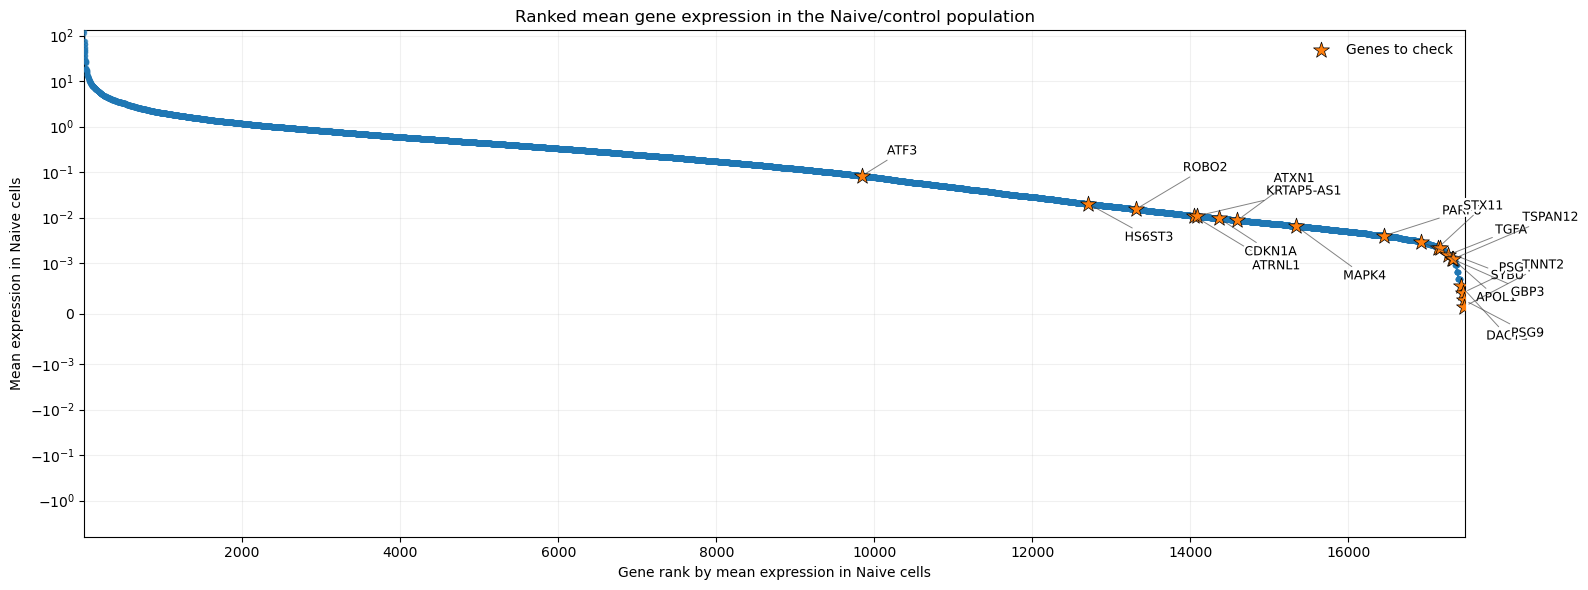

In [7]:
R.fig_naive_control_ranked_mean()

## Naive-control ranked mean-expression, all genes (log, clear labels)

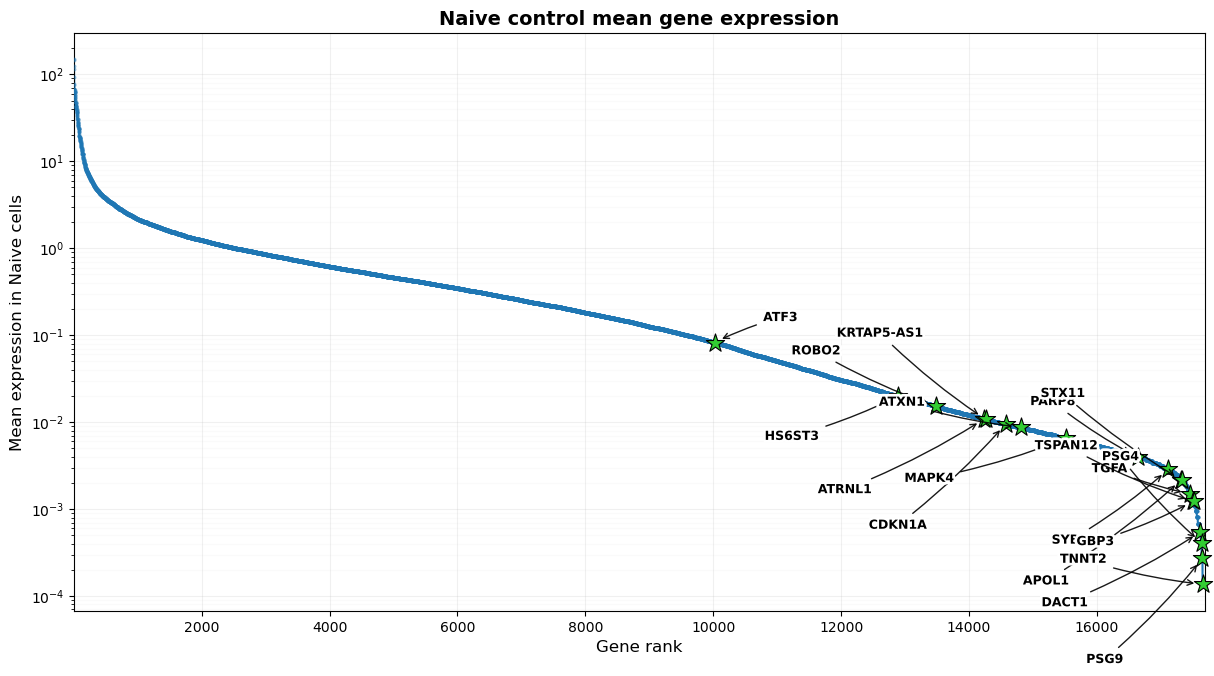

In [8]:
R.fig_naive_all_genes_mean()